# Dia 5 — Orquestrador com Skills e Sub-agente (LangGraph)

No Dia 4 aprendemos a construir grafos com LangGraph — um único agente com controle explícito do fluxo.  
Hoje vamos um passo além: **dois agentes que colaboram**, cada um com sua própria responsabilidade.

O problema que resolvemos:
> O usuário pede genericamente *"envia um alerta de falha"*.  
> O sistema precisa saber **como** escrever esse alerta — tom, formato, campos obrigatórios.  
> Esse conhecimento fica em arquivos `.md` chamados **skills**.

> 💡 **Conceito central do dia:** *Orquestrador / Sub-agente* — dividir responsabilidades entre agentes. O orquestrador decide **o quê** fazer; o sub-agente especializado sabe **como** fazer.

### Arquitetura

```
Usuário
   ↓ pedido genérico
Orquestrador (StateGraph)  — 2 tools: enviar_alerta / send_email
   │
   ├─ enviar_alerta(tipo, detalhes)   ← alertas estruturados
   │    └─ Sub-agente de alertas (StateGraph)
   │          ├─ read_skill(filename=...) → como formatar
   │          ├─ listar_destinatarios() → para quem enviar
   │          └─ send_email() × N → envia cada e-mail
   │
   └─ send_email(to, subject, body)   ← e-mails simples e diretos
```

| Parte | Tema |
|---|---|
| Setup | Conexões, credenciais, skills em disco |
| A | Tool `read_skill` |
| B | Injetar headers no system prompt do sub-agente |
| C | Sub-agente de alertas (`read_skill` + `listar_destinatarios` + `send_email`) |
| D | Orquestrador (`enviar_alerta` + `send_email`) |
| E | Testes end-to-end |

---


## Setup

In [4]:
!pip install -q langchain-anthropic langchain langgraph


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\mnsmferr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Configuramos as credenciais e definimos onde os arquivos de skill (`.md`) ficam armazenados. No Colab usamos o Google Drive para persistência; localmente, uma pasta `skills/` no diretório atual.

In [33]:
PROXY_URL      = "https://interview-server-mocado.b60gda.easypanel.host/"
ALUNO_TOKEN    = "xpto_aluno-01"

EMAIL_URL      = "https://interview-email-server.b60gda.easypanel.host/"
EMAIL_TOKEN    = "aluno-01"
EMAIL_PASSWORD = "1234"

try:
    from google.colab import drive
    drive.mount("/content/drive")
    SKILLS_FOLDER = "/content/drive/MyDrive/curso_agentes/skills"
    print(f"Google Drive montado. Skills em: {SKILLS_FOLDER}")
except ImportError:
    SKILLS_FOLDER = "skills"
    print(f"Executando localmente. Skills em: {SKILLS_FOLDER}")

print("Credenciais carregadas.")

Executando localmente. Skills em: skills
Credenciais carregadas.


Criamos os dois arquivos de skill em disco. Cada skill é um `.md` com cabeçalho de metadados (nome, descrição, palavras-chave) e instruções detalhadas de formatação para o sub-agente seguir rigorosamente.

In [18]:
import os

os.makedirs(SKILLS_FOLDER, exist_ok=True)

SKILL_FALHA = """# skill: alerta_falha
# descricao: Instrui como redigir um e-mail de alerta de falha crítica no sistema.
# palavras-chave: falha, erro, crítico, down, indisponível

---

## Instruções para o agente orquestrador

Você deve redigir um e-mail de **alerta de falha crítica** seguindo rigorosamente o formato abaixo.

### Formato obrigatório do corpo do e-mail

🚨 ALERTA DE FALHA CRÍTICA

**Sistema afetado:** [nome do sistema ou componente]
**Severidade:** CRÍTICA
**Horário da ocorrência:** [horário informado ou "não informado"]

**O que aconteceu:**
[descrição breve da falha em 1-2 frases]

**Impacto:**
[descreva quem ou o que é afetado]

**Ação necessária:**
[o que o time deve fazer agora]

— Sistema de Monitoramento Automático

### Regras de formatação
- Sempre iniciar com o emoji 🚨 e o título em CAIXA ALTA
- O campo Severidade deve ser sempre CRÍTICA
- Assunto do e-mail deve seguir o padrão: [FALHA] <nome do sistema>
- Destinatários: todos os usuários da lista fornecida pelo orquestrador
"""

SKILL_PRODUCAO = """# skill: alerta_producao
# descricao: Instrui como redigir um e-mail comemorativo de meta de produção atingida.
# palavras-chave: produção, meta, atingida, sucesso, meta batida, resultado

---

## Instruções para o agente orquestrador

Você deve redigir um e-mail de **celebração de meta de produção atingida** seguindo o formato abaixo.

### Formato obrigatório do corpo do e-mail

✅ META DE PRODUÇÃO ATINGIDA

**Linha / Área:** [nome da linha ou área]
**Meta estabelecida:** [valor da meta]
**Resultado alcançado:** [valor atingido]
**Período:** [período informado ou "turno atual"]

Parabéns ao time! 🎉
[mensagem motivacional curta de 1-2 frases]

**Próximos passos:**
[o que acontece agora]

— Sistema de Monitoramento de Produção

### Regras de formatação
- Sempre iniciar com o emoji ✅ e o título em CAIXA ALTA
- O campo Resultado alcançado deve aparecer em destaque
- Assunto do e-mail deve seguir o padrão: [PRODUÇÃO] Meta atingida — <área>
- Destinatários: todos os usuários da lista fornecida pelo orquestrador
"""

with open(f"{SKILLS_FOLDER}/alerta_falha.md", "w", encoding="utf-8") as f:
    f.write(SKILL_FALHA)

with open(f"{SKILLS_FOLDER}/alerta_producao.md", "w", encoding="utf-8") as f:
    f.write(SKILL_PRODUCAO)

print(f"Skills criadas em '{SKILLS_FOLDER}':")
for a in sorted(os.listdir(SKILLS_FOLDER)):
    print(f"  - {a}")

Skills criadas em 'skills':
  - alerta_falha.md
  - alerta_producao.md


Configuramos o LLM e fazemos login no servidor de e-mail.

In [34]:
import requests
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage

llm = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    api_key=ALUNO_TOKEN,
    base_url=PROXY_URL,
    max_tokens=1024,
)

resp = llm.invoke([HumanMessage(content="Responda apenas: conexão ok!")])
print("LLM:", resp.content)

login = requests.post(f"{EMAIL_URL}/auth/login", json={
    "token": EMAIL_TOKEN, "password": EMAIL_PASSWORD,
})
assert login.status_code == 200
_headers = {"Authorization": f"Bearer {EMAIL_TOKEN}"}
print("Email server: OK →", login.json())

LLM: Conexão ok!
Email server: OK → {'token': 'aluno-01', 'name': 'Aluno 1', 'email': 'aluno01@curso.ia'}


Definimos `send_email` com um parâmetro `sender` adicional. Alertas são enviados de `nao_responda@curso.ia` — assim o remetente fica claro para os destinatários.

In [35]:
from langchain_core.tools import tool
from typing import Optional

@tool
def send_email(
    to: str,
    subject: str,
    body: str,
    cc: Optional[str] = None,
    sender: str = "nao_responda@curso.ia",
) -> str:
    """Envia um e-mail pelo servidor do curso.

    Args:
        to: E-mail do destinatário (ex: aluno02@curso.ia)
        subject: Assunto do e-mail
        body: Corpo completo do e-mail
        cc: E-mails em cópia, separados por vírgula (opcional)
        sender: Remetente do e-mail (padrão: nao_responda@curso.ia)
    """
    payload = {"to": to, "subject": subject, "body": body, "sender": sender}
    if cc:
        payload["cc"] = cc
    r = requests.post(f"{EMAIL_URL}/emails/send", headers=_headers, json=payload)
    if r.status_code in (200, 201):
        return f"E-mail enviado com sucesso para '{to}'."
    return f"Erro ao enviar ({r.status_code}): {r.json()}"

print("Tool send_email pronta.")

Tool send_email pronta.


---
## Parte A — Tool `read_skill`

Idêntica ao Dia 5 — lê arquivos `.md` da pasta de skills.

In [36]:
HEADER_LINES = 4

@tool
def read_skill(header_only: bool, filename: Optional[str] = None) -> str:
    """Lê arquivos de skill (.md) da pasta de skills.

    Use header_only=False para ler as instruções completas de uma skill específica.

    Args:
        header_only: True para escanear cabeçalhos, False para ler completo.
        filename: Nome do arquivo .md (necessário quando header_only=False).
    """
    if header_only:
        resultado = []
        try:
            arquivos = sorted(f for f in os.listdir(SKILLS_FOLDER) if f.endswith(".md"))
        except FileNotFoundError:
            return f"Pasta de skills não encontrada: '{SKILLS_FOLDER}'"
        if not arquivos:
            return "Nenhuma skill encontrada na pasta."
        for arq in arquivos:
            caminho = os.path.join(SKILLS_FOLDER, arq)
            with open(caminho, "r", encoding="utf-8") as f:
                linhas = [f.readline() for _ in range(HEADER_LINES)]
            resultado.append(f"=== {arq} ===")
            resultado.append("".join(linhas).strip())
            resultado.append("")
        return "\n".join(resultado)
    else:
        if not filename:
            return "Erro: filename é obrigatório quando header_only=False."
        caminho = os.path.join(SKILLS_FOLDER, filename)
        if not os.path.exists(caminho):
            return f"Arquivo '{filename}' não encontrado em '{SKILLS_FOLDER}'."
        with open(caminho, "r", encoding="utf-8") as f:
            return f.read()

print(read_skill.invoke({"header_only": True}))

=== alerta_falha.md ===
# skill: alerta_falha
# descricao: Instrui como redigir um e-mail de alerta de falha crítica no sistema.
# palavras-chave: falha, erro, crítico, down, indisponível

=== alerta_producao.md ===
# skill: alerta_producao
# descricao: Instrui como redigir um e-mail comemorativo de meta de produção atingida.
# palavras-chave: produção, meta, atingida, sucesso, meta batida, resultado



---
## Parte B — Injetar headers no system prompt do sub-agente

Lemos os cabeçalhos uma vez no setup e injetamos no system prompt do **sub-agente** — não do orquestrador.

O sub-agente precisa saber quais arquivos existem para escolher o correto.  
O orquestrador **não precisa saber disso** — ele só sabe que pode chamar `consultar_skill`.

In [37]:
def montar_contexto_skills() -> str:
    try:
        arquivos = sorted(f for f in os.listdir(SKILLS_FOLDER) if f.endswith(".md"))
    except FileNotFoundError:
        return ""
    if not arquivos:
        return ""

    linhas = ["Você tem acesso às seguintes skills:\n"]
    for arq in arquivos:
        caminho = os.path.join(SKILLS_FOLDER, arq)
        with open(caminho, "r", encoding="utf-8") as f:
            header = "".join(f.readline() for _ in range(HEADER_LINES))
        linhas.append(f"- Arquivo: {arq}\n{header.strip()}\n")

    linhas.append(
        "Quando precisar das instruções completas de uma skill, "
        "use read_skill(header_only=False, filename='nome_do_arquivo.md')."
    )
    return "\n".join(linhas)


SKILLS_CONTEXT = montar_contexto_skills()
print("=== Contexto para o system prompt ===")
print(SKILLS_CONTEXT)

=== Contexto para o system prompt ===
Você tem acesso às seguintes skills:

- Arquivo: alerta_falha.md
# skill: alerta_falha
# descricao: Instrui como redigir um e-mail de alerta de falha crítica no sistema.
# palavras-chave: falha, erro, crítico, down, indisponível

- Arquivo: alerta_producao.md
# skill: alerta_producao
# descricao: Instrui como redigir um e-mail comemorativo de meta de produção atingida.
# palavras-chave: produção, meta, atingida, sucesso, meta batida, resultado

Quando precisar das instruções completas de uma skill, use read_skill(header_only=False, filename='nome_do_arquivo.md').


---
## Parte C — Sub-agente de alertas como `StateGraph`

O sub-agente é especializado em **enviar alertas** — não apenas ler skills.

Ele tem acesso a três tools: `read_skill`, `listar_destinatarios` e `send_email`.  
Recebe o tipo e os detalhes do alerta, decide qual skill usar, compõe e envia os e-mails sozinho.  
O orquestrador só chama `enviar_alerta` — não sabe como o e-mail é composto nem quem são os destinatários.

```
START → sub_agente (LLM) → [tem tool call?]
                                ↓ sim
                         tools (read_skill / listar_destinatarios / send_email)
                                ↓
                        sub_agente (LLM) → END
```

In [38]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Lista de destinatários — gerenciada pelo sub-agente
TODOS_USUARIOS = [
    "aluno01@curso.ia",
    "aluno02@curso.ia",
    "aluno03@curso.ia",
    "aluno04@curso.ia",
    "aluno05@curso.ia",
]

@tool
def listar_destinatarios() -> str:
    """Retorna a lista de todos os usuários que devem receber alertas do sistema."""
    return "Destinatários:\n" + "\n".join(f"- {u}" for u in TODOS_USUARIOS)

# Sub-agente tem acesso a leitura de skills, destinatários e envio
alerta_tools = [read_skill, listar_destinatarios, send_email]
llm_alerta = llm.bind_tools(alerta_tools)

SUB_SYSTEM_PROMPT = (
    "Você é um sub-agente especializado em envio de alertas.\n"
    "Quando receber um pedido de alerta, siga este processo:\n\n"
    "1. Use read_skill(header_only=False, filename=...) para ler as instruções da skill correta.\n"
    "2. Use listar_destinatarios para obter a lista de destinatários.\n"
    "3. Componha o e-mail seguindo RIGOROSAMENTE as instruções da skill.\n"
    "4. Envie para CADA destinatário usando send_email.\n"
    "5. Responda confirmando quantos e-mails foram enviados e para quem.\n\n"
    f"{SKILLS_CONTEXT}"
)

def no_sub_agente(state: State) -> dict:
    msgs = [SystemMessage(content=SUB_SYSTEM_PROMPT)] + list(state["messages"])
    resposta = llm_alerta.invoke(msgs)
    return {"messages": [resposta]}

def sub_agente_para_onde(state: State) -> str:
    ultima = state["messages"][-1]
    if hasattr(ultima, "tool_calls") and ultima.tool_calls:
        return "tools"
    return END

no_alerta_tools = ToolNode(alerta_tools)

builder_sub = StateGraph(State)
builder_sub.add_node("sub_agente", no_sub_agente)
builder_sub.add_node("tools", no_alerta_tools)
builder_sub.add_edge(START, "sub_agente")
builder_sub.add_conditional_edges(
    "sub_agente",
    sub_agente_para_onde,
    {"tools": "tools", END: END},
)
builder_sub.add_edge("tools", "sub_agente")

grafo_sub_agente = builder_sub.compile()
print("Sub-agente de alertas (StateGraph) compilado.")

Sub-agente de alertas (StateGraph) compilado.


Visualizamos o grafo do sub-agente. O ciclo `sub_agente → tools → sub_agente` se repete até que o LLM conclua o trabalho e retorne sem tool calls.

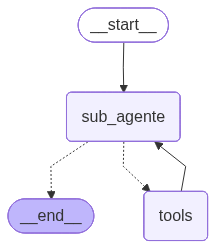

In [39]:
from IPython.display import Image
Image(grafo_sub_agente.get_graph().draw_mermaid_png())

Definimos `enviar_alerta` — a tool que o orquestrador usa para delegar ao sub-agente. O flag `VERBOSE` controla se os passos internos do sub-agente são impressos em tempo real durante a execução.

In [40]:
VERBOSE = False  # controlado por invocar_verbose

def _print_tool_call(nome, args, indent=""):
    """Imprime uma tool call formatando args longos em múltiplas linhas."""
    args_curtos = {k: v for k, v in args.items() if len(str(v)) <= 80}
    args_longos = {k: v for k, v in args.items() if len(str(v)) > 80}

    linha = ", ".join(f'{k}="{v}"' for k, v in args_curtos.items())
    print(f"{indent}→ {nome}({linha})")
    for k, v in args_longos.items():
        print(f"{indent}   {k}=")
        for linha in str(v).splitlines():
            print(f"{indent}     {linha}")


@tool
def enviar_alerta(tipo_de_alerta: str, detalhes: str) -> str:
    """Delega o envio completo de um alerta ao sub-agente especializado.

    O sub-agente irá ler as instruções da skill correta, compor e enviar os e-mails.

    Args:
        tipo_de_alerta: Tipo do alerta (ex: "falha crítica", "meta de produção atingida")
        detalhes: Informações específicas do alerta (ex: "sistema de pagamentos fora do ar desde 14h")
    """
    mensagem = f"Tipo de alerta: {tipo_de_alerta}\nDetalhes: {detalhes}"

    if not VERBOSE:
        resultado = grafo_sub_agente.invoke(
            {"messages": [HumanMessage(content=mensagem)]},
        )
        return resultado["messages"][-1].content

    # Modo verbose: faz stream do sub-agente e imprime cada passo sem truncamento
    ultima = ""
    for evento in grafo_sub_agente.stream(
        {"messages": [HumanMessage(content=mensagem)]},
        stream_mode="updates",
    ):
        for _, dados in evento.items():
            for m in dados.get("messages", []):
                if hasattr(m, "tool_calls") and m.tool_calls:
                    for stc in m.tool_calls:
                        _print_tool_call(stc["name"], stc["args"], indent="  [sub-agente] ")
                elif hasattr(m, "name") and m.name:
                    print(f"  [sub-agente] ← {m.name}:")
                    for linha in m.content.splitlines():
                        print(f"               {linha}")
                elif m.content:
                    ultima = m.content
                    print(f"  [sub-agente] ✓")
                    for linha in m.content.splitlines():
                        print(f"               {linha}")
    return ultima

print("Tool enviar_alerta pronta.")

Tool enviar_alerta pronta.


---
## Parte D — Orquestrador como `StateGraph`

O orquestrador tem **duas tools**:

| Tool | Quando usar |
|---|---|
| `enviar_alerta(tipo, detalhes)` | Alertas estruturados — delega ao sub-agente que lê a skill e envia para todos |
| `send_email(to, subject, body)` | E-mails simples e diretos a um destinatário específico |

Essa separação é a essência do padrão orquestrador/sub-agente: o orquestrador decide **o quê** e **como**; para operações complexas delega, para operações simples age diretamente.

In [41]:
orq_tools = [enviar_alerta, send_email]
llm_orq = llm.bind_tools(orq_tools)

ORQ_SYSTEM_PROMPT = (
    "Você é o agente orquestrador de comunicações.\n"
    "Você tem duas tools disponíveis:\n\n"
    "- enviar_alerta(tipo_de_alerta, detalhes): use para alertas estruturados "
    "(falha, produção, incidente). O sub-agente cuida do formato e envia para todos os destinatários.\n"
    "- send_email(to, subject, body): use para e-mails simples e diretos a um destinatário específico.\n\n"
    "Escolha a tool certa para cada pedido."
)

def no_orquestrador(state: State) -> dict:
    msgs = [SystemMessage(content=ORQ_SYSTEM_PROMPT)] + list(state["messages"])
    resposta = llm_orq.invoke(msgs)
    return {"messages": [resposta]}

def orq_para_onde(state: State) -> str:
    ultima = state["messages"][-1]
    if hasattr(ultima, "tool_calls") and ultima.tool_calls:
        return "tools"
    return END

no_orq_tools = ToolNode(orq_tools)

builder_orq = StateGraph(State)
builder_orq.add_node("orquestrador", no_orquestrador)
builder_orq.add_node("tools", no_orq_tools)
builder_orq.add_edge(START, "orquestrador")
builder_orq.add_conditional_edges(
    "orquestrador",
    orq_para_onde,
    {"tools": "tools", END: END},
)
builder_orq.add_edge("tools", "orquestrador")

grafo_orquestrador = builder_orq.compile()
print("Orquestrador (StateGraph) compilado.")

Orquestrador (StateGraph) compilado.


Visualizamos o grafo do orquestrador. Estruturalmente idêntico ao sub-agente, mas com tools diferentes: `enviar_alerta` (delega ao sub-agente) e `send_email` (age diretamente).

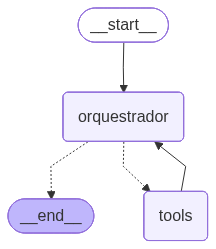

In [42]:
Image(grafo_orquestrador.get_graph().draw_mermaid_png())

---
## Parte E — Testes end-to-end

In [43]:
def invocar_orquestrador(prompt: str) -> str:
    resultado = grafo_orquestrador.invoke(
        {"messages": [HumanMessage(content=prompt)]},
        config={"recursion_limit": 20},
    )
    return resultado["messages"][-1].content


def invocar_verbose(prompt: str) -> str:
    """Executa mostrando cada passo do orquestrador e do sub-agente."""
    global VERBOSE
    VERBOSE = True
    print(f"[usuário] {prompt}\n")
    ultima_resposta = ""

    try:
        for evento in grafo_orquestrador.stream(
            {"messages": [HumanMessage(content=prompt)]},
            config={"recursion_limit": 20},
            stream_mode="updates",
        ):
            for no, dados in evento.items():
                for msg in dados.get("messages", []):
                    if hasattr(msg, "tool_calls") and msg.tool_calls:
                        for tc in msg.tool_calls:
                            args = ", ".join(f'{k}="{v}"' for k, v in tc["args"].items())
                            print(f"[orquestrador] → {tc['name']}({args})")
                    elif hasattr(msg, "name") and msg.name:
                        # ToolMessage — resultado de enviar_alerta (já impresso pelo sub-agente)
                        pass
                    elif msg.content:
                        ultima_resposta = msg.content
                        print(f"\n[orquestrador] ✓ {msg.content}")
    finally:
        VERBOSE = False

    return ultima_resposta


print("Helpers prontos.")

Helpers prontos.


Executamos os testes end-to-end. Para cada cenário, observe qual tool o orquestrador escolhe: alertas complexos vão para `enviar_alerta`; e-mails simples vão direto para `send_email`.

In [44]:
# Teste 1: alerta de falha
print("=== ALERTA DE FALHA ===")
resposta = invocar_orquestrador(
    "Envia um alerta de falha. O sistema de pagamentos está fora do ar desde as 14h."
)
print(resposta)

=== ALERTA DE FALHA ===
✅ **Alerta enviado com sucesso!**

O alerta de **falha crítica** sobre o sistema de pagamentos fora do ar desde as 14h foi despachado para **5 destinatários**. O sub-agente formatou a mensagem seguindo as instruções de severidade crítica e todos os e-mails foram entregues.


**E-mail simples:** o orquestrador reconhece que não há alerta estruturado e usa `send_email` diretamente — sem acionar o sub-agente.

In [45]:
# Teste 1: e-mail simples — orquestrador usa send_email diretamente
print("=== E-MAIL SIMPLES ===")
resposta = invocar_orquestrador(
    "Manda um e-mail para aluno02@curso.ia com assunto 'Reunião' "
    "e corpo 'Confirmo presença na reunião de amanhã às 10h.'"
)
print(resposta)

=== E-MAIL SIMPLES ===
Pronto! O e-mail foi enviado com sucesso para aluno02@curso.ia com o assunto "Reunião" e a mensagem confirmando a presença na reunião de amanhã às 10h.


**Alerta de produção — modo verbose:** acompanhamos cada passo interno do sub-agente em tempo real: qual skill foi lida, quais destinatários foram listados, cada e-mail enviado.

In [ ]:
# Teste 2: alerta de produção atingida
print("=== META DE PRODUÇÃO ATINGIDA ===")
resposta = invocar_verbose(
    "Envia o alerta de produção. A linha 3 bateu a meta de 500 unidades neste turno."
)
print(resposta)

=== META DE PRODUÇÃO ATINGIDA ===
[usuário] Envia o alerta de produção. A linha 3 bateu a meta de 500 unidades neste turno.

[orquestrador] → enviar_alerta(tipo_de_alerta="meta de produção atingida", detalhes="Linha 3 bateu a meta de 500 unidades neste turno.")
  [sub-agente] → read_skill(header_only="False", filename="alerta_producao.md")
  [sub-agente] → listar_destinatarios()
  [sub-agente] ← read_skill:
               # skill: alerta_producao
               # descricao: Instrui como redigir um e-mail comemorativo de meta de produção atingida.
               # palavras-chave: produção, meta, atingida, sucesso, meta batida, resultado
               
               ---
               
               ## Instruções para o agente orquestrador
               
               Você deve redigir um e-mail de **celebração de meta de produção atingida** seguindo o formato abaixo.
               
               ### Formato obrigatório do corpo do e-mail
               
               ✅ META DE P

: 

**E-mail simples em modo verbose:** confirmamos que e-mails diretos não envolvem o sub-agente — o orquestrador age em um único passo.

In [31]:
# Teste 3: e-mail simples direto — orquestrador usa send_email sem sub-agente
print("=== E-MAIL SIMPLES DIRETO ===")
resposta = invocar_verbose(
    "Manda um e-mail para aluno02@curso.ia com assunto 'Lembrete' "
    "e corpo 'Reunião de alinhamento hoje às 15h.'"
)
print(resposta)

=== E-MAIL SIMPLES DIRETO ===
[usuário] Manda um e-mail para aluno02@curso.ia com assunto 'Lembrete' e corpo 'Reunião de alinhamento hoje às 15h.'

[orquestrador] → send_email(to="aluno02@curso.ia", subject="Lembrete", body="Reunião de alinhamento hoje às 15h.")

[orquestrador] ✓ Perfeito! E-mail enviado com sucesso para aluno02@curso.ia com o assunto "Lembrete" e a mensagem sobre a reunião de alinhamento às 15h.
Perfeito! E-mail enviado com sucesso para aluno02@curso.ia com o assunto "Lembrete" e a mensagem sobre a reunião de alinhamento às 15h.


Verificamos a caixa de entrada para confirmar que os e-mails enviados nos testes chegaram corretamente.

In [30]:
# Verificar e-mails recebidos
r = requests.get(f"{EMAIL_URL}/emails/inbox", headers=_headers)
inbox = r.json()
print(f"{inbox['count']} mensagem(ns) na caixa de entrada:\n")
for msg in inbox["messages"]:
    print(f"  [{msg['id']}] De: {msg['from']:<25} | {msg['subject']}")

0 mensagem(ns) na caixa de entrada:



---
## Resumo do Dia 5

### Separação de responsabilidades

| Agente | Tools | Responsabilidade |
|---|---|---|
| Sub-agente | `read_skill`, `listar_destinatarios`, `send_email` | Sabe COMO e PARA QUEM enviar alertas |
| Orquestrador | `enviar_alerta`, `send_email` | Decide entre delegar (alerta) ou agir diretamente (e-mail simples) |

### Padrão orquestrador / sub-agente

- **Delegar** (`enviar_alerta`) → quando a operação é complexa: envolve decisão (qual skill?), múltiplos destinatários, formato estruturado
- **Agir diretamente** (`send_email`) → quando a operação é simples: destinatário e conteúdo já conhecidos

### Quando usar cada camada

- **`create_agent`** → fluxo linear, sem bifurcações, prototipagem rápida
- **LangGraph** → quando você precisa de controle explícito, HITL, ou bifurcações condicionais

---

### 🎓 Fim do curso — o que você construiu ao longo dos 5 dias

| Dia | Conceito-chave | O que ficou |
|---|---|---|
| 1 | Tools com `@tool` e agente multi-tool básico | Um agente que envia e-mails e gerencia agenda |
| 2 | Memória persistente, thread isolation e middleware HITL | Histórico por sessão + aprovação humana antes de agir |
| 3 | RAG — o agente consulta conhecimento externo | Busca semântica num catálogo de produtos com FAISS |
| 4 | LangGraph — controle de fluxo explícito e `interrupt()` | Bifurcação condicional e pausa para aprovação humana |
| 5 | Orquestrador / sub-agente — delegação e especialização | Sistema de alertas automáticos com skills em arquivos `.md` |
